In [1]:
#remotes::install_github("jinworks/CellChat@88c2e13")

suppressPackageStartupMessages({
    library(CellChat)
    library(zellkonverter)
    library(SingleCellExperiment())
})



In [2]:
library(tidyr)
library(tibble)


Attaching package: ‘tidyr’


The following object is masked from ‘package:S4Vectors’:

    expand


The following object is masked from ‘package:igraph’:

    crossing



Attaching package: ‘tibble’


The following object is masked from ‘package:igraph’:

    as_data_frame




In [8]:
dist_out_dir <- "/home/workspace/spatial_mouse_lung_outputs/downstream_analysis/distance"
dist_out_dir_cellchat <- "/home/workspace/spatial_mouse_lung_outputs/downstream_analysis/distance/cellchat_tls-category"
plot_out_dir <- file.path(dist_out_dir_cellchat, "plots")

## Load cellchat results

In [4]:
# name = "HDM_day3"
# path =  file.path(dist_out_dir_cellchat, paste0("cellchat_",name,".rds"))
# cellchat <- readRDS(path)

In [5]:
name = "HDM_day3"
path =  file.path(dist_out_dir_cellchat, paste0("cellchat_trim05_",name,".rds"))
cellchat <- readRDS(path)

In [ ]:
# run compute centrality score, a necessary step for many of the downstream cellchat plots
cellchat <- netAnalysis_computeCentrality(cellchat, slot.name = "netP")

In [37]:
create_plots <- function(cellchat) {
    # # change the order of the labels
    # cellchat@meta$labels <- forcats::fct_relevel(cellchat@meta$labels, "P14 top", "P14 crypt", "P14 muscularis")
    # cellchat <- updateClusterLabels(cellchat, new.order = levels(cellchat@meta$labels))

    # cellchat <- netAnalysis_computeCentrality(cellchat, slot.name = "netP")

    pdf(file = file.path(plot_out_dir, "signaling_role.pdf"))
    plot(netAnalysis_signalingRole_heatmap(cellchat, pattern = "incoming"))
    plot.new()
    plot(netAnalysis_signalingRole_heatmap(cellchat, pattern = "outgoing"))
    dev.off()
}

In [38]:
create_plots(cellchat)

png 
  2

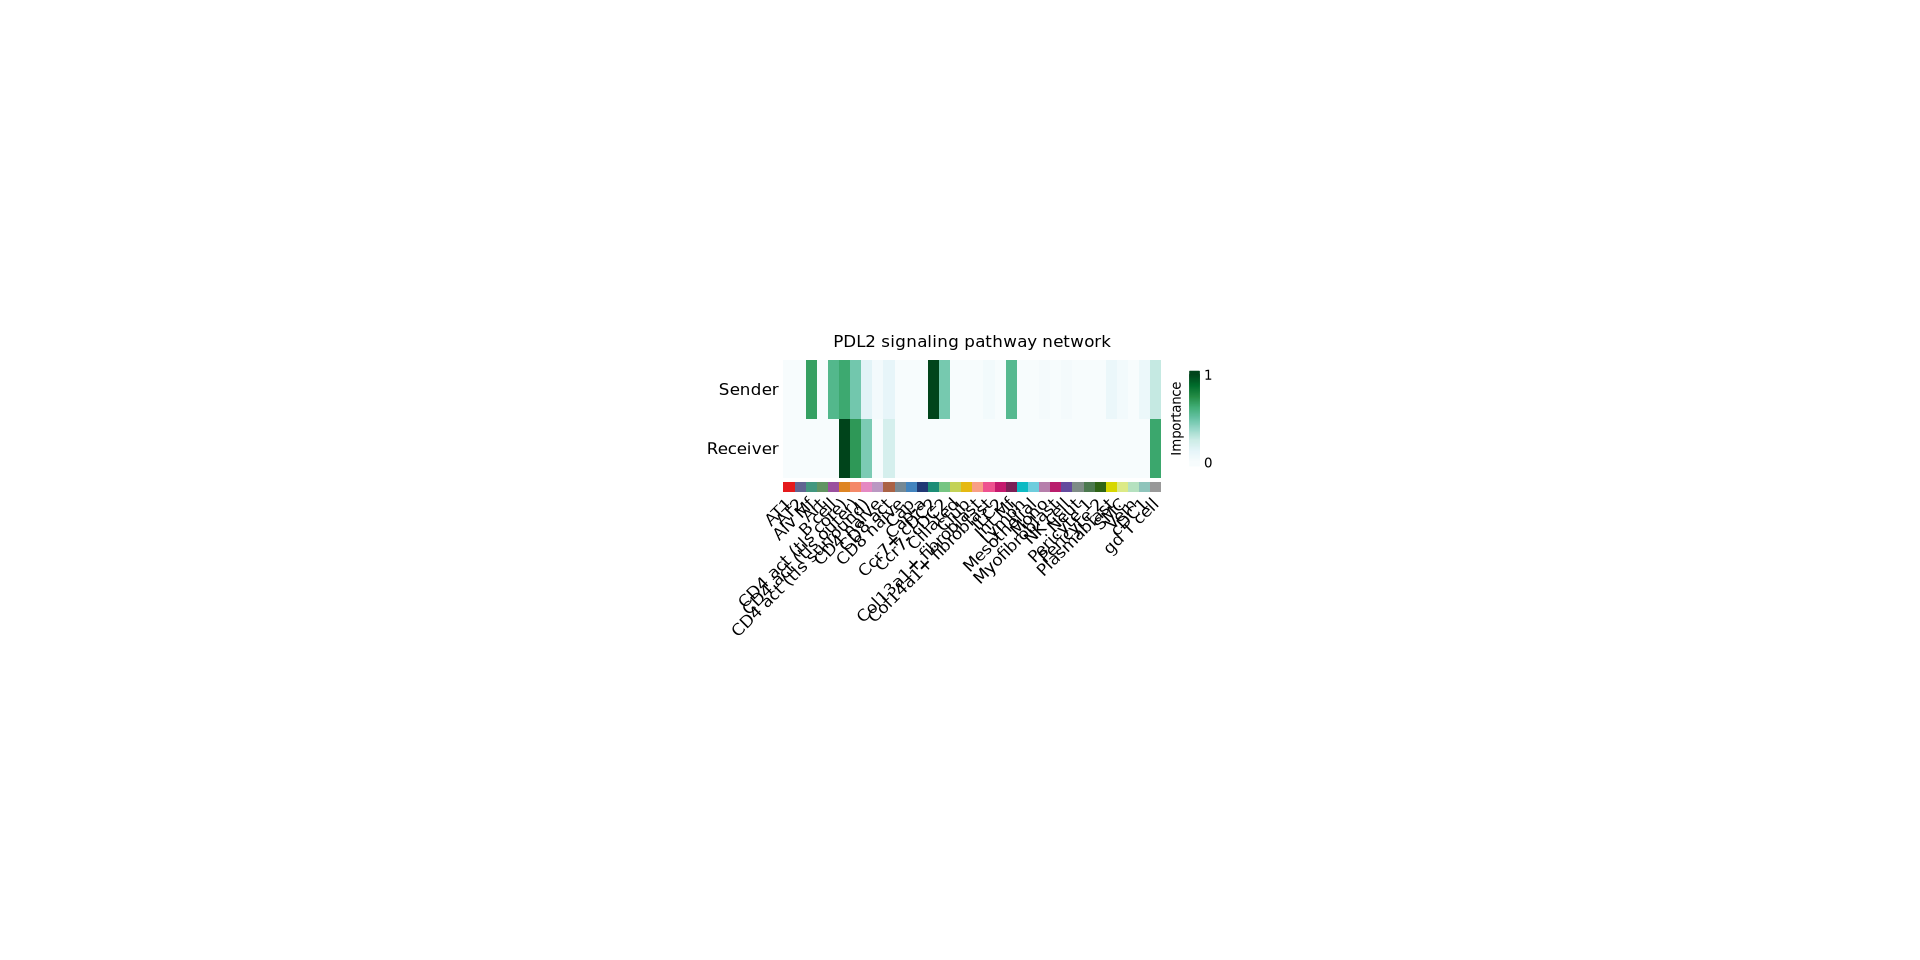

In [35]:
pathways.show <- c("PDL2")
netAnalysis_signalingRole_network(cellchat, signaling = pathways.show,
                                  measure = c("outdeg", "indeg"), measure.name = c("Sender", "Receiver"), # exclude , "Mediator", "Influencer"
                                  width = 8, height = 2.5, font.size = 10)


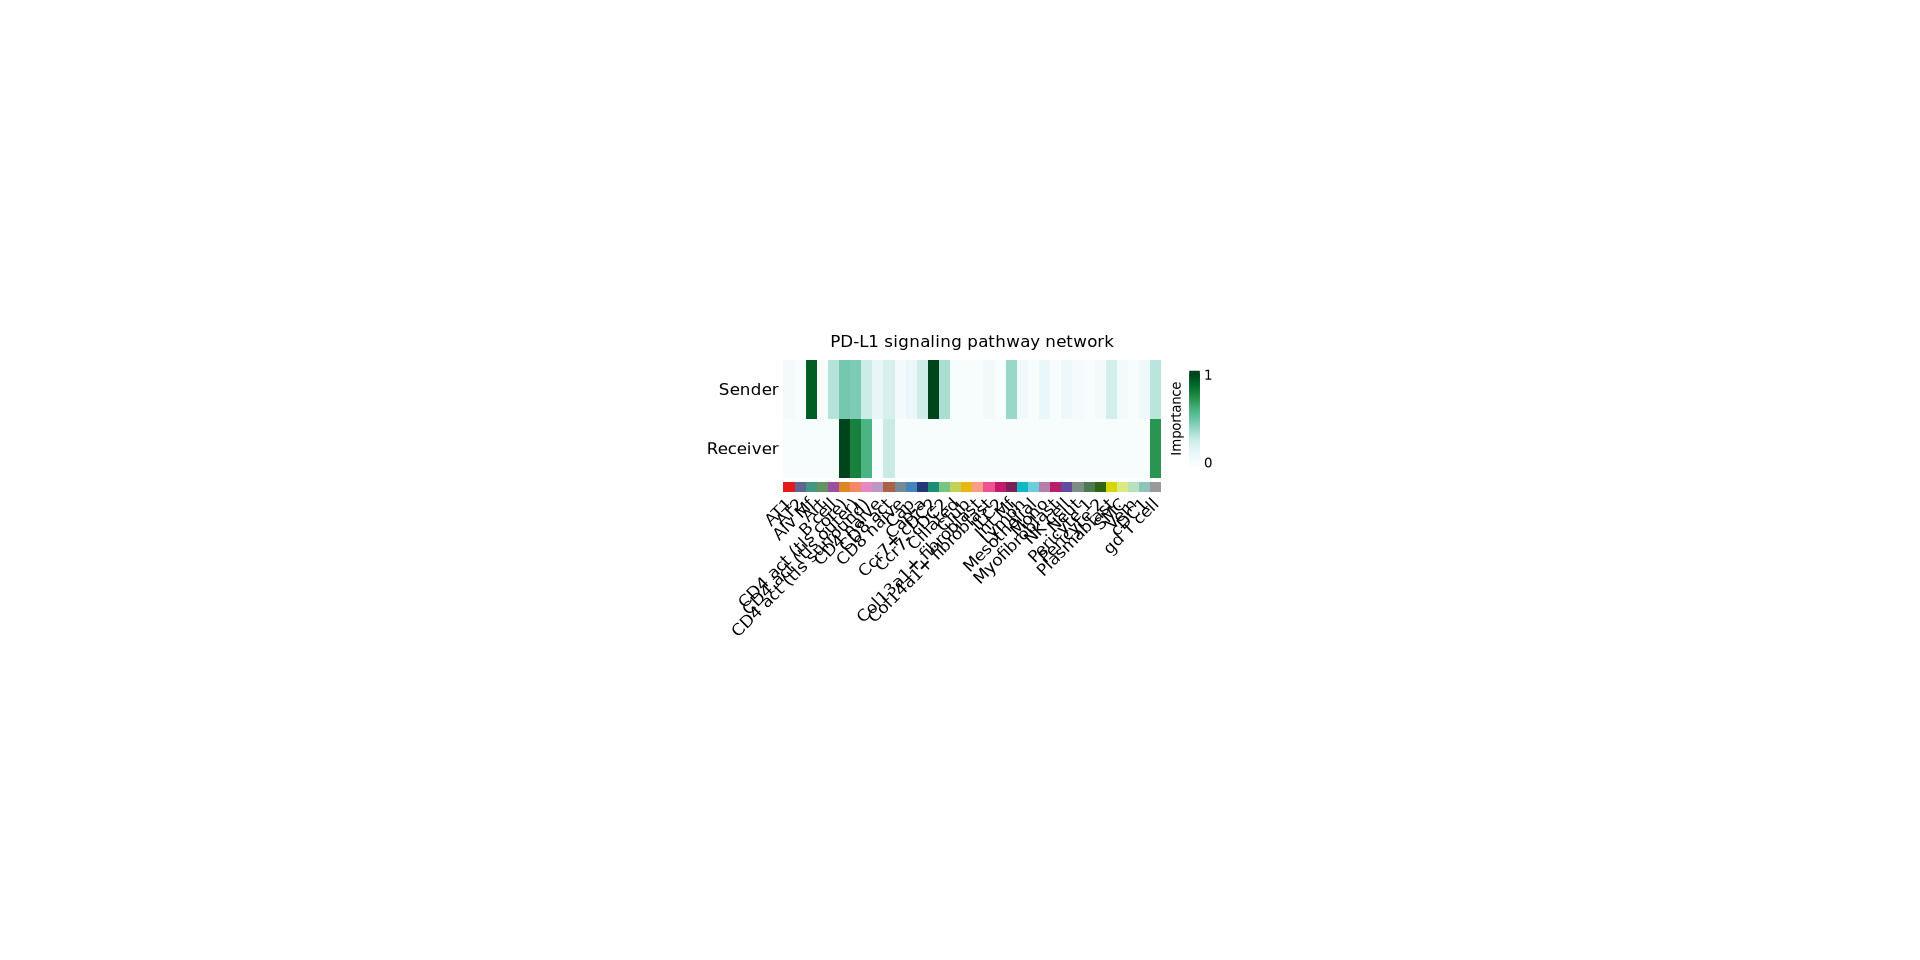

In [36]:
pathways.show <- c("PD-L1")
netAnalysis_signalingRole_network(cellchat, signaling = pathways.show,
                                  measure = c("outdeg", "indeg"), measure.name = c("Sender", "Receiver"), # exclude , "Mediator", "Influencer"
                                  width = 8, height = 2.5, font.size = 10)

In [34]:
# spatialFeaturePlot(cellchat, features = c("Pdcd1lg2","Pdcd1"), point.size = 0.8, color.heatmap = "Reds", direction = 1)
# spatialFeaturePlot(cellchat, features = c("Cd274","Pdcd1"), point.size = 0.8, color.heatmap = "Reds", direction = 1)

In [16]:
cellchat@netP$inbound

NULL

In [19]:
sources <- c('B cell',
 'AT2',
 'gd T cell',
 'Int Mf',
 'Cap',
 'Col14a1+ fibroblast',
 'Th0',
 'Plasmablast',
 'Alv Mf',
 'cDC1')

Comparing communications on a single object 




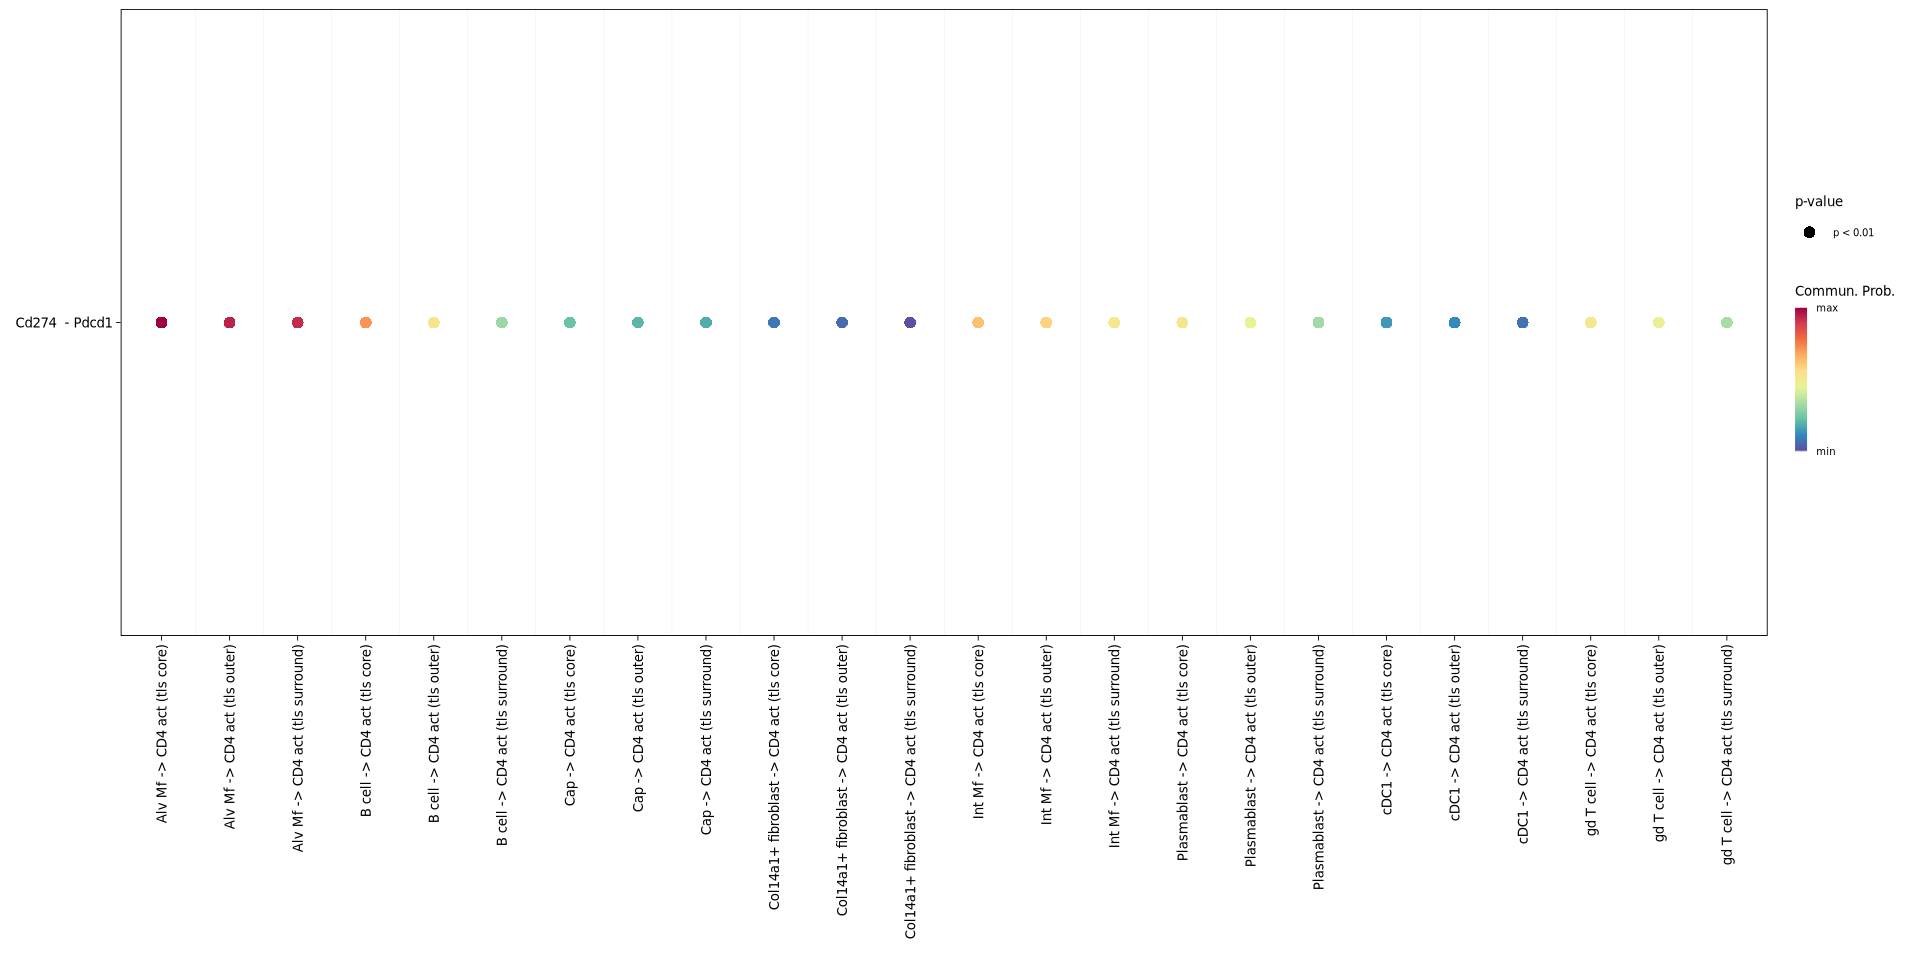

In [20]:
options(repr.plot.width = 16, repr.plot.height = 8)
netVisual_bubble(
  cellchat,
  sources.use = sources,
  targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
  signaling = "PD-L1",  
    # pairLR.use = pairLR.use,
    remove.isolate = TRUE, 
)

Comparing communications on a single object 




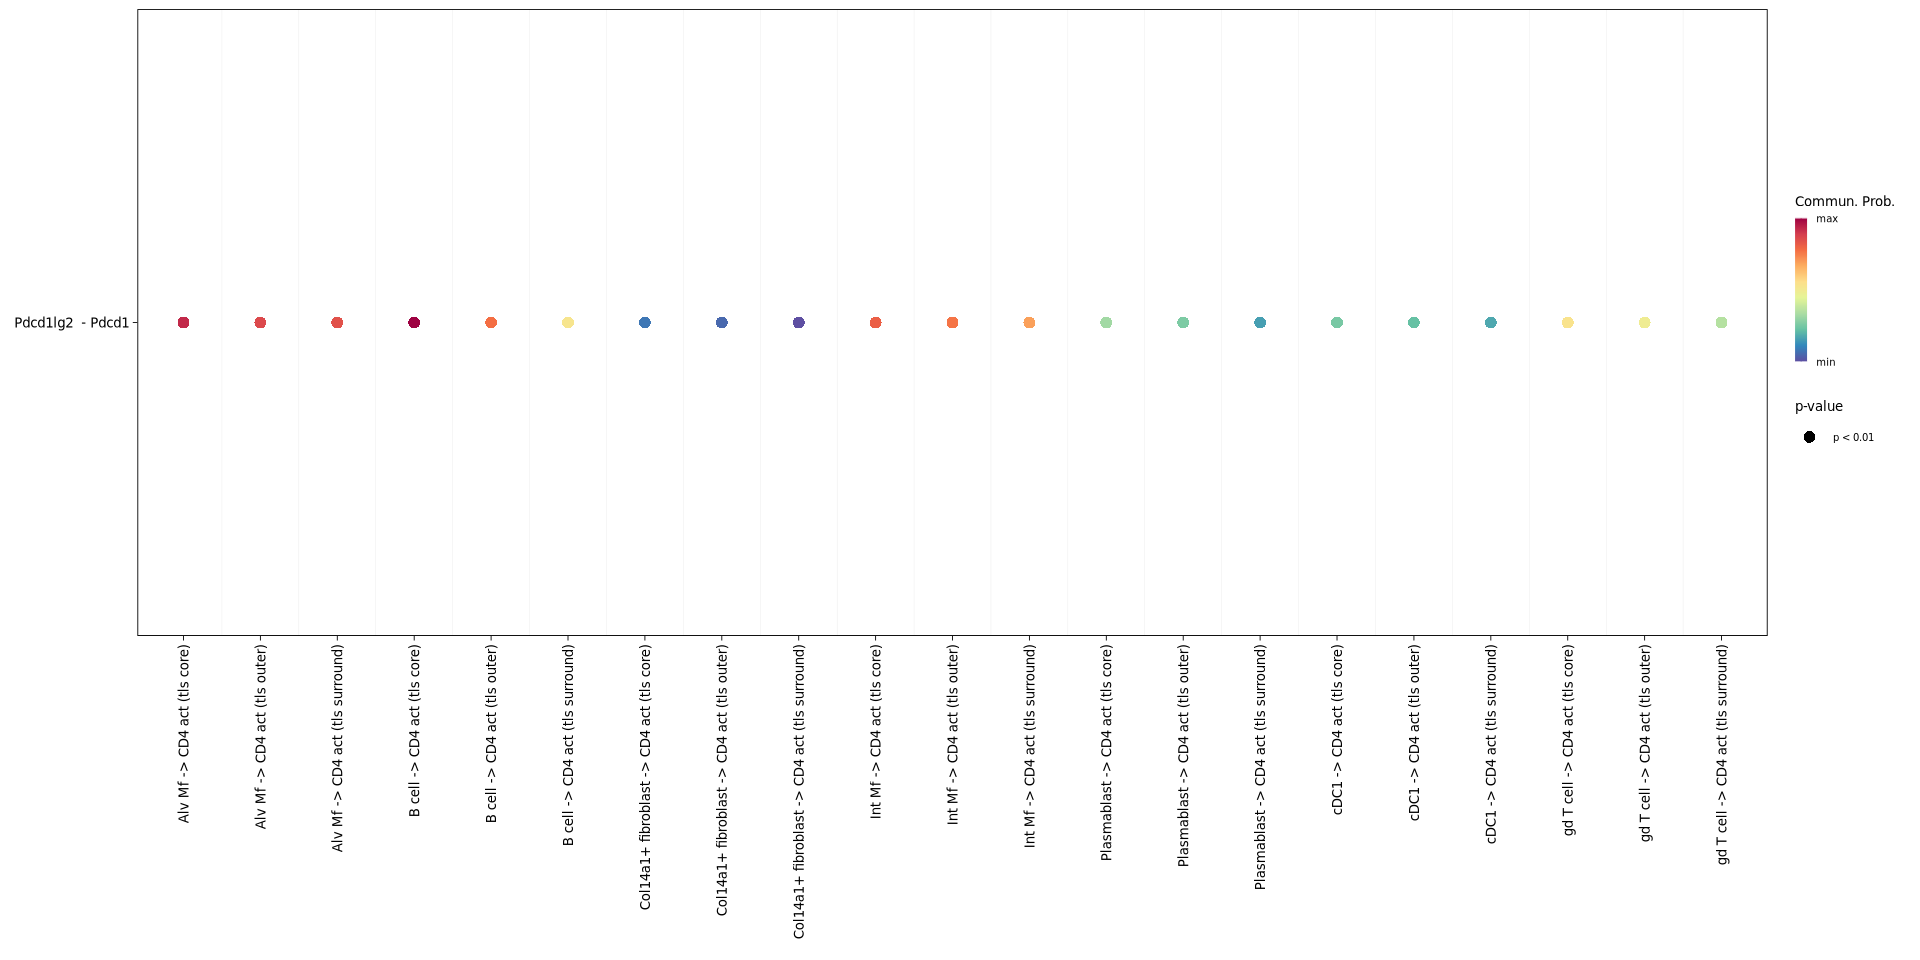

In [22]:
options(repr.plot.width = 16, repr.plot.height = 8)
netVisual_bubble(
  cellchat,
  sources.use = sources,
  targets.use = c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'),
  signaling = "PDL2",  
    # pairLR.use = pairLR.use,
    remove.isolate = TRUE, 
)

In [ ]:
df.net <- subsetCommunication(cellchat)
# df.net[df.net$ligand == "Il33", ]

cd4_targets <- c('CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)')
df.net.cd4 <- df.net %>% filter(target %in% cd4_targets)
unique(df.net.cd4$ligand)
df.ligand <- df.net.cd4 %>% filter(ligand == "Ccl19")

df.ligand.summary <- df.ligand %>%
  group_by(target) %>%
  summarise(total_prob = sum(prob, na.rm = TRUE)) %>%
  ungroup()

ggplot(df.ligand.summary, aes(x = target, y = total_prob)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  labs(
    title = "Total Ligand Signaling to CD4 act Subsets",
    x = "CD4 act Subset (Target)",
    y = "Summed Interaction Probability"
  ) +
  theme_minimal()

In [ ]:
df.ligand

In [ ]:
# netVisual_chord_gene(
#   cellchat,
#   signaling = "TGFb",
#   sources.use = NULL,
#   targets.use = c("CD4 act (TLS)", "CD4 act (parenchyma)", "CD4 act (adventitia)"),
#   lab.cex = 1.2
# )

In [ ]:
capitalize <- function(x) {
  sapply(x, function(s) {
    paste0(toupper(substr(s, 1, 1)), tolower(substr(s, 2, nchar(s))))
  }, USE.NAMES = FALSE)
}

# now make a heatmap with all ligands and cluster by rows 

ligands <- unique(df.net.cd4$ligand)

# Step 1: Filter and summarize (already done)
cd4_targets <- c('CD4 act (TLS)', 'CD4 act (parenchyma)', 'CD4 act (adventitia)')

df.filtered <- df.net %>%
  filter(target %in% cd4_targets, ligand %in% ligands, pval < 0.05)

df.summary <- df.filtered %>%
  group_by(ligand, target) %>%
  summarise(total_prob = sum(prob, na.rm = TRUE), .groups = "drop")



# Step 2: Pivot to wide format (ligands as rows, targets as columns)
heatmap_matrix <- df.summary %>%
  pivot_wider(names_from = target, values_from = total_prob, values_fill = 0)
row_labels <- heatmap_matrix$ligand

# Step 3: Set rownames, remove ligand column, then scale across rows
rownames(heatmap_matrix) <- heatmap_matrix$ligand
heatmap_scaled <- heatmap_matrix[, -1]

# Scale each row (ligand) using z-score
heatmap_scaled_z <- t(scale(t(as.matrix(heatmap_scaled)), center = TRUE, scale = TRUE))



# Compute row (ligand) clustering
dist_rows <- dist(heatmap_scaled_z)
clust_rows <- hclust(dist_rows, method = "complete")  # or "average", "ward.D2", etc.

# Reorder ligands by clustering
ordered_ligands <- row_labels[clust_rows$order]





# Step 4: Convert back to tidy format for ggplot
heatmap_scaled_z_df <- as.data.frame(heatmap_scaled_z)
heatmap_scaled_z_df$ligand = heatmap_matrix$ligand
# heatmap_scaled_z_df$ligand <- rownames(heatmap_scaled_z_df)

df.heatmap <- pivot_longer(
  heatmap_scaled_z_df,
  cols = -ligand,
  names_to = "target",
  values_to = "z_score"
)

df.heatmap$ligand <- factor(df.heatmap$ligand, levels = ordered_ligands)

# Step 5: Plot
# print(
p <- ggplot(df.heatmap, aes(x = target, y = ligand, fill = z_score)) +
  geom_tile(color = "white") +
  scale_fill_gradient2(low = "purple", mid = "white", high = "orange", midpoint = 0) +
  labs(
      title='by zone',
    x = "",
    y = "",
    fill = "Ligand z-score"
  ) +     
scale_x_discrete(labels = c(
      'CD4 act (TLS)' = "T",
      'CD4 act (adventitia)' = "A",
      'CD4 act (parenchyma)' = "P"
    )) +
  theme_minimal() +
  theme(
      plot.title = element_text(size = 28),
    axis.text.x = element_text(size = 28),
    axis.text.y = element_text(size = 20),
  )
    # )

ggsave(
  filename = file.path(cellchat_out_dir, "summed_ligand_score_CD4_heatmap.pdf"),
  plot = p,  
  width = 6,            
  height = 18, 
  units = "in"
)
    # }


In [ ]:
options(repr.plot.width = 16, repr.plot.height = 8)
netVisual_bubble(
  cellchat,
  sources.use = c('Int Mf', 'Alv Mf', 'Ccr7+ cDC2', 'Ccr7- cDC2', 'cDC1'),
  targets.use = c("CD4 act (TLS)", "CD4 act (adventitia)", "CD4 act (parenchyma)"),
  signaling = "PD-L1",  
    # pairLR.use = pairLR.use,
    remove.isolate = TRUE, 
)

In [ ]:
pairLR.use <- extractEnrichedLR(cellchat, signaling = c("CCL"))
pairLR.use

netVisual_bubble(
  cellchat,
  sources.use = NULL, # or your sender cells of interest
  targets.use = c("CD4 act (TLS)"),
  # signaling = "CXCL",  # OR any ligand/receptor/pathway
    pairLR.use = pairLR.use,
    remove.isolate = TRUE, 
)

netVisual_bubble(
  cellchat,
  sources.use = NULL, # or your sender cells of interest
  targets.use = c("CD4 act (adventitia)"),
  # signaling = "CXCL",  # OR any ligand/receptor/pathway
    pairLR.use = pairLR.use,
    remove.isolate = TRUE, 
)

netVisual_bubble(
  cellchat,
  sources.use = NULL, # or your sender cells of interest
  targets.use = c("CD4 act (parenchyma)"),
  # signaling = "CXCL",  # OR any ligand/receptor/pathway
    pairLR.use = pairLR.use,
    remove.isolate = TRUE, 
)

## Try some visualizations

In [ ]:
cellchat <- netAnalysis_computeCentrality(cellchat, slot.name = "net")

In [ ]:
cellchat

In [ ]:
pdf(file = file.path(cellchat_out_dir, paste0("cc_LR_",name,".pdf")))
plot(netAnalysis_signalingRole_heatmap(cellchat, pattern = "incoming"))
plot.new()
plot(netAnalysis_signalingRole_heatmap(cellchat, pattern = "outgoing"))
dev.off()

### plot interactions received 

In [ ]:
print(netVisual_chord_gene(cellchat, sources.use = c("B cell"), targets.use = c("CD4 act (TLS)")))
print(netVisual_chord_gene(cellchat, sources.use = c("B cell"), targets.use = c("CD4 act (adventitia)")))
print(netVisual_chord_gene(cellchat, sources.use = c("B cell"), targets.use = c("CD4 act (parenchyma)")))

## Figure 3g and extended data figure 3d

In [ ]:
create_plots <- function(cellchat_out_dir, name) {
    path =  file.path(cellchat_out_dir, paste0("cellchat_",name,".rds"))
    cellchat <- readRDS(path)
    # # change the order of the labels
    # cellchat@meta$labels <- forcats::fct_relevel(cellchat@meta$labels, "P14 top", "P14 crypt", "P14 muscularis")
    # cellchat <- updateClusterLabels(cellchat, new.order = levels(cellchat@meta$labels))

    cellchat <- netAnalysis_computeCentrality(cellchat, slot.name = "netP")

    pdf(file = file.path(cellchat_out_dir, paste0("cc_",name,".pdf")))
    plot(netAnalysis_signalingRole_heatmap(cellchat, pattern = "incoming"))
    plot.new()
    plot(netAnalysis_signalingRole_heatmap(cellchat, pattern = "outgoing"))
    dev.off()
}

In [ ]:
name = "HDM_day3"
create_plots(cellchat_out_dir, name)

In [ ]:
# Loop over different datasets
for (dataset in c("d7", "d30", "full")) {
  # Load the CellChat object for the current dataset
  cellchat <- readRDS(paste0("tmp/cellchat_", dataset, ".rds"))
  pathways.show <- c("TGFb") 
  
  vertex.receiver <- which(levels(cellchat@idents) %in% c("T Cells (epithelial)", "T Cells (stromal)", "T Cells (neither)"))
  
  # Create the visualization
  p <- netVisual_individual(cellchat, signaling = pathways.show, layout = 'circle', targets.use=vertex.receiver)
  
  # Save as PDF with dataset-specific filename
  pdf(paste0("out/TGFb_network_visualization_", dataset, ".pdf"), width = 8, height = 8)
  print(p)
  dev.off()
  
  # Store the plot for the last dataset to display in notebook
  if (dataset == "full") {
    p_display <- p
  }
}

# Set p to the last plot for display in the notebook
p <- p_display

# Display in notebook
p


In [ ]:
# Loop over different datasets
for (dataset in c("d7", "d30", "full")) {
  # Load the CellChat object for the current dataset
  cellchat <- readRDS(paste0("tmp/cellchat_", dataset, ".rds"))
  pathways.show <- c("CCL") 
  
  vertex.receiver <- which(levels(cellchat@idents) %in% c("T Cells (epithelial)", "T Cells (stromal)", "T Cells (neither)"))
  
  # Create the visualization
  p <- netVisual_individual(cellchat, signaling = pathways.show, layout = 'circle', targets.use=vertex.receiver)
  
  # Save as PDF with dataset-specific filename
  pdf(paste0("out/CCL_network_visualization_", dataset, ".pdf"), width = 8, height = 8)
  print(p)
  dev.off()
  
  # Store the plot for the last dataset to display in notebook
  if (dataset == "full") {
    p_display <- p
  }
}

# Set p to the last plot for display in the notebook
p <- p_display

# Display in notebook
p


In [ ]:
# Loop over different datasets
for (dataset in c("d7", "d30", "full")) {
  # Load the CellChat object for the current dataset
  cellchat <- readRDS(paste0("tmp/cellchat_", dataset, ".rds"))
  pathways.show <- c("CXCL") 
  
  vertex.receiver <- which(levels(cellchat@idents) %in% c("T Cells (epithelial)", "T Cells (stromal)", "T Cells (neither)"))
  
  # Create the visualization
  p <- netVisual_individual(cellchat, signaling = pathways.show, layout = 'circle', targets.use=vertex.receiver)
  
  # Save as PDF with dataset-specific filename
  pdf(paste0("out/CXCL_network_visualization_", dataset, ".pdf"), width = 8, height = 8)
  print(p)
  dev.off()
  
  # Store the plot for the last dataset to display in notebook
  if (dataset == "full") {
    p_display <- p
  }
}

# Set p to the last plot for display in the notebook
p <- p_display

# Display in notebook
p


In [ ]:
# Loop over different datasets
for (dataset in c("d7", "d30", "full")) {
  # Load the CellChat object for the current dataset
  cellchat <- readRDS(paste0("tmp/cellchat_", dataset, ".rds"))
  pathways.show <- c("CXCL") 
  
  vertex.receiver <- which(levels(cellchat@idents) %in% c("T Cells (epithelial)", "T Cells (stromal)", "T Cells (neither)"))
  
  # Create the visualization
  p <- netVisual_individual(cellchat, signaling = pathways.show, layout = 'circle', targets.use=vertex.receiver)
  
  # Save as PDF with dataset-specific filename
  pdf(paste0("out/CXCL_network_visualization_", dataset, ".pdf"), width = 8, height = 8)
  print(p)
  dev.off()
  
  # Store the plot for the last dataset to display in notebook
  if (dataset == "full") {
    p_display <- p
  }
}

# Set p to the last plot for display in the notebook
p <- p_display

# Display in notebook
p


In [ ]:
# Loop over different datasets
for (dataset in c("d7", "d30", "full")) {
  # Load the CellChat object for the current dataset
  cellchat <- readRDS(paste0("tmp/cellchat_", dataset, ".rds"))
  pathways.show <- c("IL2") 
  
  vertex.receiver <- which(levels(cellchat@idents) %in% c("T Cells (epithelial)", "T Cells (stromal)", "T Cells (neither)"))
  
  # Create the visualization
  p <- netVisual_individual(cellchat, signaling = pathways.show, layout = 'circle', targets.use=vertex.receiver)
  
  # Save as PDF with dataset-specific filename
  pdf(paste0("out/IL2_network_visualization_", dataset, ".pdf"), width = 8, height = 8)
  print(p)
  dev.off()
  
  # Store the plot for the last dataset to display in notebook
  if (dataset == "full") {
    p_display <- p
  }
}

# Set p to the last plot for display in the notebook
p <- p_display

# Display in notebook
p
